(ode:integration-schemes:mechanical-system)=
# Time-integration of a mechanical system



Reference to:

* [Modal and numerical methods for mechanical systems - continuum mechanics](https://basics2022.github.io/bbooks-physics-continuum-mechanics/ch/solids/small-displacements-numerics.html)
* [Natural modes in structures - blog](https://basics2022.github.io/myblog/posts/modes-in-structures/)

## Example equation: torsion of elastic beam

Here, the PDE governing the torsional dynamics of a linear homogeneous elastic beam is used as a toy problem

$$I \partial_{tt} \theta - \partial_x \left( GJ \partial_{x} \theta \right) = m $$

supplied with proper boundary and initial conditions. Here the clamped-free beam is studied, with prescribed torsional moment $M(t)$ ath teh "free" end so that the boundary conditions read

$$\begin{aligned}
 \theta(x=0, t) & = 0 \\
 GJ \partial_x \theta(x=\ell, t) & = M(t) \ .
\end{aligned}$$

See
* [Continuum mechanics: Beams](https://basics2022.github.io/bbooks-physics-continuum-mechanics/ch/solids/beams.html)
* [Continuum mechanics: Timoshenko beam](https://basics2022.github.io/bbooks-physics-continuum-mechanics/ch/solids/beams/timoshenko.html)
* [Finite element methods for beam structures](https://basics2022.github.io/bbooks-physics-continuum-mechanics/ch/solids/small-displacements-fem-beams.html)


### Exact solution

### Finite element model

Semi-discretized model in space

$$\begin{aligned}
 \int_{z=0}^{\ell} w(z) m(z,t) \, dz
 & = \int_{z=0}^{\ell} w(z) \left\{ I \partial_{tt} \theta - \partial_x \left(GJ \partial_x \theta \right) \right\} \, dz = \\
 & = \int_{z=0}^{\ell} w(z) I \partial_{tt} \theta(z,t) \, dz + \int_{z=0}^{\ell} \partial_x w(z) GJ \partial_x \theta(z,t) \, dz - \left.\left[ w(x) GJ \partial_x \theta(x,t) \right]\right|_{z=0}^{\ell} \ .
\end{aligned}$$

With the boundary conditions of the model, the FEM approximation of the problem becomes

$$\begin{aligned}
 \int_{z=0}^{\ell} w(z) m(z,t) \, dz + w(\ell) M(t) 
 & = \int_{z=0}^{\ell} w(z) I \partial_{tt} \theta(z,t) \, dz + \int_{z=0}^{\ell} \partial_x w(z) GJ \partial_x \theta(z,t) \, dz \ .
\end{aligned}$$

In [62]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix

def assemble_fem_matrices(L, N, I_coeff, GJ_coeff):
    """
    Assembles Sparse Mass and Stiffness matrices for P1 Lagrange elements
    based on 'Screenshot from 2026-05-14 18-59-39.png'.
    """
    # Grid setup
    nodes = np.linspace(0, L, N + 1)
    h = L / N  # element width
    num_nodes = N + 1

    # Local Element Matrices for P1 Lagrange
    # Mass Matrix Local: (h/6) * [[2, 1], [1, 2]]
    m_local = (I_coeff * h / 6.0) * np.array([[2.0, 1.0], 
                                              [1.0, 2.0]])
    
    # Stiffness Matrix Local: (1/h) * [[1, -1], [-1, 1]]
    k_local = (GJ_coeff / h) * np.array([[1.0, -1.0], 
                                         [-1.0, 1.0]])

    # Global Assembly using COO format for efficiency
    rows = []
    cols = []
    mass_data = []
    stiff_data = []

    for i in range(N):
        # Indices for the current element (nodes i and i+1)
        idx = [i, i + 1]
        
        for r in range(2):
            for c in range(2):
                rows.append(idx[r])
                cols.append(idx[c])
                mass_data.append(m_local[r, c])
                stiff_data.append(k_local[r, c])

    # Convert to CSR (Compressed Sparse Row) format
    M_sparse = csr_matrix((mass_data, (rows, cols)), shape=(num_nodes, num_nodes))
    K_sparse = csr_matrix((stiff_data, (rows, cols)), shape=(num_nodes, num_nodes))

    return M_sparse, K_sparse

def get_partitioned_matrices(L, N, I_coeff, GJ_coeff, dirichlet_indices):
    # 1. Reuse the assembly logic to get global matrices
    # (Assuming the assembly function from the previous step is defined)
    M_global, K_global = assemble_fem_matrices(L, N, I_coeff, GJ_coeff)
    
    num_nodes = N + 1
    
    # 2. Define Node Sets
    # Node 0 is Dirichlet (index 0), all others are Free
    all_indices = np.arange(num_nodes)
    free_indices = np.setdiff1d(all_indices, dir_indices)
    
    # 3. Partitioning: Extract the FF block (Free-Free)
    # This effectively removes the first row and first column
    M_ff = M_global[free_indices, :][:, free_indices]
    K_ff = K_global[free_indices, :][:, free_indices]
    
    return M_ff, K_ff, free_indices


# Example parameters
L = 1.0           # Length of the domain
N = 10            # Number of elements
I_val = 1.0       # Inertia coefficient (from image)
GJ_val = 1.0      # Torsional stiffness (from image)
dir_indices = [0] # Dirichlet indices of the nodes with prescribed displacement
Mff, Kff, free_indices = get_partitioned_matrices(L, N, I_val, GJ_val, dir_indices)

print(f"Mass Matrix Shape: {Mff.shape}")
print(f"Mass      Matrix (First 3x3 block):\n{Mff.toarray()[:3, :3]}")
print(f"Stiffness Matrix (First 3x3 block):\n{Kff.toarray()[:3, :3]}")
print(f"Sum(Mass Matrix): {np.sum(Mff.toarray())}")


Mass Matrix Shape: (10, 10)
Mass      Matrix (First 3x3 block):
[[0.06666667 0.01666667 0.        ]
 [0.01666667 0.06666667 0.01666667]
 [0.         0.01666667 0.06666667]]
Stiffness Matrix (First 3x3 block):
[[ 20. -10.   0.]
 [-10.  20. -10.]
 [  0. -10.  20.]]
Sum(Mass Matrix): 0.9333333333333333


## Boundary conditions

Matrix partition or augmented system.

### Matrix partition

$$\begin{aligned}
  \mathbf{f}
  & = \mathbf{M} \ddot{\mathbf{x}} + \mathbf{K} \mathbf{x} \\
\end{aligned}$$

$$\begin{aligned}
  \begin{bmatrix} \mathbf{f}_f \\ \mathbf{f}_d \end{bmatrix} & = 
  \begin{bmatrix} \mathbf{M}_{ff} & \mathbf{M}_{fd} \\ \mathbf{M}_{df} & \mathbf{M}_{dd} \end{bmatrix} \begin{bmatrix} \ddot{\mathbf{x}}_{f} \\ \ddot{\mathbf{x}}_d \end{bmatrix} + 
  \begin{bmatrix} \mathbf{K}_{ff} & \mathbf{K}_{fd} \\ \mathbf{K}_{df} & \mathbf{K}_{dd} \end{bmatrix} \begin{bmatrix} \mathbf{x}_{f} \\ \mathbf{x}_d \end{bmatrix}
\end{aligned}$$

Here the value of the kinematic variables $\mathbf{x}_d$, and the actions $\mathbf{f}_f$ is known. The unknowns are $\mathbf{x}_f$ (the displacement of the free d.o.f.s of the system), and $\mathbf{f}_d$ (the reactions at the constraints). Separating the unknowns from the known quantities,

$$\begin{aligned}
  \mathbf{M}_{ff} \ddot{\mathbf{x}}_f + \mathbf{K}_{ff} \mathbf{x}_f & = \mathbf{f}_f - \mathbf{M}_{fd} \ddot{\mathbf{x}}_d - \mathbf{K}_{fd} \mathbf{x}_d \\
  \mathbf{f}_d & = - \begin{bmatrix} \mathbf{M}_{df} & \mathbf{M}_{dd} \end{bmatrix} \begin{bmatrix} \ddot{\mathbf{x}}_f \\ \ddot{\mathbf{x}}_d \end{bmatrix} - \begin{bmatrix} \mathbf{K}_{df} & \mathbf{K}_{dd} \end{bmatrix} \begin{bmatrix} \mathbf{x}_f \\ \mathbf{x}_d \end{bmatrix}
\end{aligned}$$

This system is decoupled, as the reactions at the constraints are not involved in the dynamical systems for $\mathbf{x}_f$, and thus they can be computed a posteriori.

### Augmented system

See the discussion about Poisson equation - i.e. the static version of the dynamical equation used here, with no inertia contribution - in [Math: Numerical methods for PDEs](https://basics2022.github.io/bbooks-math-miscellanea/ch/pde/numerics.html)
* [FEM: Poisson equation. Augmenting the linear system](https://basics2022.github.io/bbooks-math-miscellanea/ch/pde/fem-poisson-1d.html#augmenting-the-linear-system)
* [FVM: Poisson equation. Augmenting the linear system](https://basics2022.github.io/bbooks-math-miscellanea/ch/pde/fvm-poisson-1d.html#augmenting-the-linear-system)



#### Spectral decomposition of the undamped system

Eigenvalue problem focuses on the free response of the system, so all the forcing terms - both prescribed actions in $\mathbf{f}_f$ and prescribed kinetic variables in $\mathbf{x}_d$ - are set equal to zero. Thus, it's possible to focus on the $f$-part of the partitioned system only, $\mathbf{M}_{ff} \ddot{\mathbf{x}}_f + \mathbf{K}_{ff} \mathbf{x}_f = \dots$. In the following lines, pedices are dropped.

Either generalized eigenvalue problem of the undamped system as a second-order $n$-dimensional system

$$\mathbf{M} \ddot{\mathbf{x}} + \mathbf{K} \mathbf{x} = \mathbf{f} \ ,$$

$$s^2 \mathbf{M} \mathbf{x} + \mathbf{K} \mathbf{x} = \mathbf{0}$$

or the generalized eigenvalue problem as a first-order $2n$-dimensional system

$$\begin{aligned}
  \begin{bmatrix} \mathbf{I} & \cdot \\ \cdot & \mathbf{M} \end{bmatrix} \begin{bmatrix} \dot{\mathbf{x}} \\ \dot{\mathbf{v}} \end{bmatrix} +
  \begin{bmatrix} \cdot & - \mathbf{I} \\ \mathbf{K} & \cdot \end{bmatrix} \begin{bmatrix} \mathbf{x} \\ \mathbf{v} \end{bmatrix} = \begin{bmatrix} \mathbf{0} \\ \mathbf{f} \end{bmatrix} \ .
\end{aligned}$$

$$s \mathbf{A} \mathbf{z} + \mathbf{B} \mathbf{z} = \mathbf{0}$$


**Matrix symmetries and routines.**
* In the second-orded system, matrices of a mechanical system are usually symmetric. It's possible to use the routine for Hermitian matrices $\texttt{.eigsh()}$

* In the first-orded system, the augmented matrices are not symmetric. It's not possible to use the routine for Hermitian matrices. Use the routine for general matrix $\texttt{.eigs()}$ instead


**Solution of the eigenvalue problem, and diagonalization - modal form.** Routines returns mass normalized eigenvectors, so that

$$\mathbf{V}^* \mathbf{M} \mathbf{V} = \mathbf{I} \ .$$

As the matrix form of the generalized eigenvalue problem reads $\mathbf{M} \mathbf{V} \mathbf{S}^2 + \mathbf{K} \mathbf{V} = \mathbf{0}$. 


Changing basis from "nodal" to "modal" variables, $\mathbf{x} = \mathbf{V} \mathbf{q}$, and projecting on the eigenvectors, the dynamical equation becomes

$$\begin{aligned}
  \mathbf{V}^* \mathbf{f} & = \mathbf{V}^* \left( \mathbf{M} \mathbf{V} \ddot{\mathbf{u}} + \mathbf{K} \mathbf{V} \mathbf{u} \right) \\
  \mathbf{V}^* \mathbf{f} & = \ddot{\mathbf{u}} + \text{diag} \left\{ - s_i^2 \right\} \mathbf{u} = \\
   & = \ddot{\mathbf{u}} + \text{diag} \left\{ \Omega_i^2 \right\} \mathbf{u} \ .
\end{aligned}$$


For a mechanical system with definite positive $\mathbf{M}$ and $\mathbf{K}$, the eigenvalues of the system are imaginary so that $s_i^2 = - \Omega^2_i$.

In [72]:

import scipy as sp

#> Solve generalized sparse eigenvalue problem with symmetric matrices, s^2 M x + K x = 0
# evals, evecs = eigsh(A, k=6, M=None, which='LM', ...)
# for solving the A v = s M v problem
# k=number of evals, evecs computed. k < n (not possible to evaluate all the evals with this routine,
# but usually sparse matrix is used for large matrices, and one is not interested in the whole spectrum.
# For small matrices, either convert to full matrix or use this routine twice, one looking for SM and one for LM
# which='LM': largest magnitude, 'SM': smallest magnitude
evals_, evecs = sp.sparse.linalg.eigsh(Kff, k=N-1, M=Mff, which='SM')

#> Here evals^2 = - evals_
# evals are imaginary, \mp j \omega
evals = np.sqrt( -np.real(evals_) - 1j * np.imag(evals_) )

# print(f"First 3 Omega (rad/s): {np.abs(np.imag(evals[:3]))}")
# print("First 3 eigenvectors:")
# print(evecs[:,:3])

#> Run the routine twice to get eigenvalues with largest magnitude, and assemble them with the eigenvalues with smallest magnitude
#> If the full decomposition is required, just used the same routing twice: evaluate SM(k=kSM), and then
# evaluate LM(k=kLM), with kSM+kLM = N
#> As the routine is runned twice without sharing any info, apply normalization (if it's meaningful) later
# If kSM=N-1, then kLM=1 (without coincident eigvalues with largest magnitude), the eigenvectors could be already
# normal. By default the routine returns a mass-normalized eigenvectors
evals_lm_, evecs_lm = sp.sparse.linalg.eigsh(Kff, k=1, M=Mff, which='LM')
evals_lm = np.sqrt( -np.real(evals_lm_) - 1j * np.imag(evals_lm_) )

evals_all = np.block([evals, evals_lm])
evecs_all = np.block([evecs, evecs_lm])

# print(evals_all)
# print(evecs_all)

if ( np.max( evecs_all.T @ Mff @ evecs_all - np.eye(N) ) < 1e-9 ):
    print("Mass-normalization of the eigenvectors within the tol\n")
else:
    print("Mass-normalization of the eigenvectors not satisfied, or above the tol\n")

print(evals_)


[0. +1.57241173j 0. +4.75610398j 0. +8.05707841j 0.+11.55418418j
 0.+15.3202872j  0.+19.40022863j 0.+23.75474269j 0.+28.14651567j
 0.+31.98583136j 0.+34.32358567j]
Mass-normalization of the eigenvectors within the tol

[   2.47247865   22.62052505   64.91651253  133.49917214  234.71119998
  376.36887101  564.28780011  792.22634461 1023.09340791]


In [56]:
I_sparse = sp.sparse.eye(N, format='csr')
Z_sparse = None

A = sp.sparse.bmat([
    [ I_sparse, Z_sparse ],
    [ Z_sparse,      Mff ]
])

B = sp.sparse.bmat([
    [ Z_sparse, -I_sparse ],
    [      Kff,  Z_sparse ]
])

#> Solve generalized sparse eigenvalue problem with non-symmteric matrices,
# which='xy', x: L(largest), S(smallest), y: M(magnitude), R(real part), I(imag part)
eevals, eevecs = sp.sparse.linalg.eigs(B, M=A, which='SM')

print("First 3 pairs of eigenvalues:")
print(evals)
# print("First 3 pairs of eigenvectors:")
# print(evecs[:,:6:2])

#> If the full decomposition is required, just used the same routing twice: evaluate SM(k=kSM), and then
# evaluate LM(k=kLM), with kSM+kLM = 2N
#> As the routine is runned twice without sharing any info, apply normalization (if it's meaningful) later
# If kSM=2N-2, then kLM=2 (without coincident pairs with largest magnitude), the eigenvectors could be already
# normal. By default the routine returns a mass-normalized eigenvectors
# evals, evecs = sp.sparse.linalg.eigs(B, k=4, M=A, which='LM')
# print(evals)

First 3 pairs of eigenvalues:
[0. +1.57241173j 0. +4.75610398j 0. +8.05707841j 0.+11.55418418j
 0.+15.3202872j  0.+19.40022863j 0.+23.75474269j 0.+28.14651567j
 0.+31.98583136j]


#### Modal structural damping

See 
* [Continuum mechanics: structural damping](https://basics2022.github.io/bbooks-physics-continuum-mechanics/ch/solids/structural-damping.html)
* [Sensitivity of eigenvalues and eigenvectors in a second-order system](https://basics2022.github.io/bbooks-physics-continuum-mechanics/ch/solids/structural-damping.html#sensitivity-of-eigenvalues-and-eigenvectors)
* [Sensitivity of spectral decomposition](https://basics2022.github.io/bbooks-math-miscellanea/ch/linear-algebra/spectral-sensitivity.html)

Modal damping for the simultaneous diagonalization of mass, damping and stiffness matrices.

$$\mathbf{V}^* \mathbf{f} = \ddot{\mathbf{u}} + \text{diag}\{ 2 \xi_i \Omega_i \} \dot{\mathbf{u}} + \text{diag}\{ \Omega_i^2 \} \mathbf{u}$$

i.e. with 

$$\mathbf{V}^* \mathbf{C} \mathbf{V} = \text{diag}\{ 2 \xi_i \Omega_i \}$$

so that the damping matrix in "nodal" variables reads

$$ \mathbf{C} = \mathbf{V} \text{diag}\{ 2 \xi_i \Omega_i \} \mathbf{V}^*$$


The eigenvalues of the damped system, for $\xi_i < 1$, become

$$s_i = - \xi_i \Omega_i \mp j \Omega_i \sqrt{1 - \xi_i^2} \ .$$

**Exact solution.** 

$$\begin{aligned}
  & I \ddot{\theta} - GJ \theta'' = 0  \\
  & \theta(0,t) = 0 \\
  & GJ \theta'(\ell,t) = 0 \ .
\end{aligned}$$

$$\theta(z,t) = f(x) g(t)$$

$$\frac{I}{GJ} \frac{\ddot{g}}{g} = \frac{f''}{f} = -k^2$$

$$f(z) = A \cos \left( k z \right) + B \sin \left( k z \right)$$

with boundary conditions

$$\begin{aligned}
  0 & = f(0) = A \\
  0 & = f'(\ell) = B k \cos \left( k \ell \right)
\end{aligned}$$

so that $\cos \left( k \ell \right) = 0$, and thus $k_n \ell = \frac{\pi}{2} + n \pi$, $n \in \mathbb{N}$, i.e. the wave numbers of the modes are 

$$k_n = \frac{\pi}{\ell} \left( n + \frac{1}{2} \right) \ .$$

Pulsations of the modes are

$$\omega_n = k_n \sqrt{\frac{GJ}{I}} = \frac{\pi}{\ell} \sqrt{\frac{GJ}{I}} \left( n + \frac{1}{2} \right) \ .$$


In [91]:
#> Set structural damping, diagonal in modal basis
xi = .1
xi_all = np.ones(N) * xi
Om_all = np.imag(evals_all)

#> Damping matrix in nodal basis
Cff = evecs_all @ np.diag(2*xi_all*Om_all) @ evecs_all.T


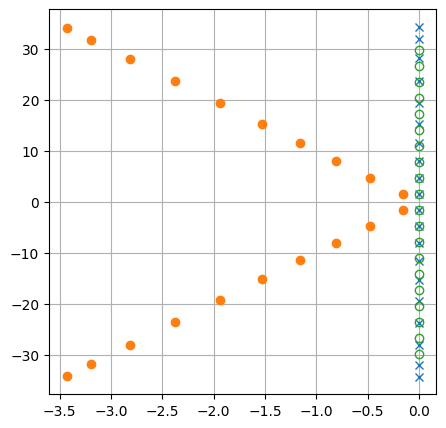

  Numerical evals     Exact evals      
 ------------------------------------- 
  0.0000 -1.5724 i   0.0000 -1.5708 i
  0.0000 -4.7561 i   0.0000 -4.7124 i
  0.0000 -8.0571 i   0.0000 -7.8540 i
  0.0000-11.5542 i   0.0000-10.9956 i
  0.0000-15.3203 i   0.0000-14.1372 i
  0.0000-19.4002 i   0.0000-17.2788 i
  0.0000-23.7547 i   0.0000-20.4204 i
  0.0000-28.1465 i   0.0000-23.5619 i
  0.0000-31.9858 i   0.0000-26.7035 i
  0.0000-34.3236 i   0.0000-29.8451 i


In [111]:
#> Comparing eigenvalues 
# - damped discrete system
# - undamped discrete system
# - undamped continuous system (exact)

#> Exact eigenvalues
n_exact = N
om_exact_0 = np.pi / L * np.sqrt(GJ_val/I_val)
om_exact = om_exact_0 * ( .5 + np.arange(N) )
evals_exact = -1j * om_exact

evals_damped = Om_all * ( - xi_all - 1j * np.sqrt( 1 - xi_all**2 ) )
evals_undamped = - 1j* Om_all

evals_damped = np.concatenate([evals_damped, np.conj(evals_damped)])
evals_undamped = np.concatenate([evals_undamped, np.conj(evals_undamped)])
evals_exact = np.concatenate([evals_exact, np.conj(evals_exact)])

# print(Om_all)
# print(xi_all)
# print(evals_damped)

fig, ax = plt.subplots(1,1, figsize=(5,5))
ax.plot(np.real(evals_undamped), np.imag(evals_undamped), 'x')
ax.plot(np.real(evals_damped), np.imag(evals_damped), 'o')
ax.plot(np.real(evals_exact), np.imag(evals_exact), 'o', mfc='None')
# ax.set_aspect("equal")
# ax.set_xlim(-30,10)
# ax.set_ylim(-20,20)
ax.grid()

plt.show()

print("  Numerical evals     Exact evals      ")
print(" ------------------------------------- ")
for i in np.arange(N):
    print(f"{np.real(evals_undamped[i]):8.4f}{np.imag(evals_undamped[i]):8.4f} i", 
          f"{np.real(evals_exact[i]):8.4f}{np.imag(evals_exact[i]):8.4f} i")

Eigenvalues of the first modes show a good match with the exact eigenvalues. For larger wave-number modes, the modes of the discrete system have higher frequencies than the modes of the continuous system: numerical approximation introduces "numerical constraints" (as it's not capable of representing the exact solution, but only a system with a finite-number dofs), and thus makes the system "stiffer": higher frequencies of the numerical eigenvalues agree with this intuition.